# Level Break Out

### Load the data

In [140]:
import pandas as pd
import pandas_ta as ta
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy import stats

df = pd.read_csv("data/EURUSD_Candlestick_1_Hour_BID_04.05.2003-15.04.2023.csv")
df=df[df['volume']!=0]
df.reset_index(drop=True, inplace=True)

df['EMA'] = df['close'].ewm(span=25, adjust=False).mean()
df.tail()

df=df[0:10000]

### Trend detection

In [141]:
EMAsignal = [0]*len(df)
backcandles = 15

for row in range(backcandles, len(df)):
    upt = 1
    dnt = 1
    for i in range(row-backcandles, row+1):
        if max(df.open[i], df.close[i])>=df.EMA[i]:
            dnt=0
        if min(df.open[i], df.close[i])<=df.EMA[i]:
            upt=0
    if upt==1 and dnt==1:
        EMAsignal[row]=3
    elif upt==1:
        EMAsignal[row]=2
    elif dnt==1:
        EMAsignal[row]=1

df['EMASignal'] = EMAsignal

In [142]:
def isPivot(candle, window):
    """
    function that detects if a candle is a pivot/fractal point
    args: candle index, window before and after candle to test if pivot
    returns: 1 if pivot high, 2 if pivot low, 3 if both and 0 default
    """
    if candle-window < 0 or candle+window >= len(df):
        return 0
    
    pivotHigh = 1
    pivotLow = 2
    for i in range(candle-window, candle+window+1):
        low1 = df.iloc[i].low
        lowcandle = df.iloc[candle].low

        high1 = df.iloc[i].high
        highcandle = df.iloc[candle].high
        
        if df.iloc[candle].low > df.iloc[i].low:
            pivotLow=0
        if df.iloc[candle].high < df.iloc[i].high:
            pivotHigh=0
            
    if (pivotHigh and pivotLow):
        return 3
    elif pivotHigh:
        return pivotHigh
    elif pivotLow:
        return pivotLow
    else:
        return 0

In [143]:
window=10
df['isPivot'] = df.apply(lambda x: isPivot(x.name,window), axis=1)

In [144]:
def pointpos(x):
    if x['isPivot']==2:
        return x['low']-1e-3
    elif x['isPivot']==1:
        return x['high']+1e-3
    else:
        return np.nan
        
df['pointpos'] = df.apply(lambda row: pointpos(row), axis=1)

In [145]:
def detect_structure(candle, backcandles, window):
    """
    Attention! window should always be greater than the pivot window! to avoid look ahead bias
    """
    if (candle <= (backcandles+window)) or (candle+window+1 >= len(df)):
        return [0,0]

    localdf = df.iloc[candle-backcandles-window:candle-window] #window must be greater than pivot window to avoid look ahead bias
    highs = localdf[localdf['isPivot'] == 1].high.tail(3).values
    lows = localdf[localdf['isPivot'] == 2].low.tail(3).values
    
    levelbreak = 0
    pointBreak = 0
    zone_width = 0.001
    if len(lows)==3:
        support_condition = True
        mean_low = lows.mean()
        for low in lows:
            if abs(low-mean_low)>zone_width:
                support_condition = False
                break
        if support_condition and (mean_low - df.loc[candle].close)>zone_width*2:
            levelbreak = 1
            pointBreak = df.loc[candle].close - 0.010
    if len(highs)==3:
        resistance_condition = True
        mean_high = highs.mean()
        for high in highs:
            if abs(high-mean_high)>zone_width:
                resistance_condition = False
                break
        if resistance_condition and (df.loc[candle].close-mean_high)>zone_width*2:
            levelbreak = 2
            pointBreak =  df.loc[candle].close + 0.010
    return [levelbreak,pointBreak] 

In [154]:
#df['pattern_detected'] = df.index.map(lambda x: detect_structure(x, backcandles=40, window=15))
returnValue = df.apply(lambda row: detect_structure(row.name, backcandles=60, window=11), axis=1)

df['pattern_detected'] = returnValue.map(lambda x: x[0])  
df['pointBreak'] = returnValue.map(lambda x: x[1]) 
#df[df['pattern_detected'].values!=0]
#df[df['pointBreak'].values!=0.0]

df.to_csv('breakoutstr.csv', index=False)

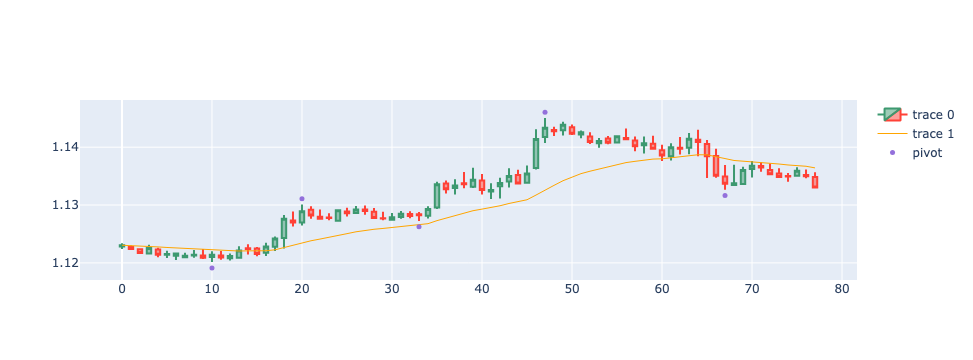

In [155]:
'''
0:78
78:156
156:234
234:312
312:390
390:468
468:546
546:624
624:702
702:780
780:858
858:936
936:1014
1014:1092
1092:1170
1170:1248
1248:1326
1326:1404
1404:1482
1482:1560
1560:1638
1638:1716
1716:1794
1794:1872
1872:1950
1950:2028
2028:2106

9000:10000 *
'''


dfpl = df[9000:10000]
fig = go.Figure(data=[go.Candlestick(x=dfpl.index,
                open=dfpl['open'],
                high=dfpl['high'],
                low=dfpl['low'],
                close=dfpl['close']),
                go.Scatter(x=dfpl.index, y=dfpl['EMA'], line=dict(color='orange', width=1))])

pointBreakIndex = dfpl[dfpl['pointBreak'] != 0].index.tolist()
pointBreakValues = list(filter((0.0).__ne__, dfpl['pointBreak']))

fig.add_scatter(x=dfpl.index, y=dfpl['pointpos'], mode="markers", marker=dict(size=5, color="MediumPurple"), name="pivot")
fig.add_scatter(x=pointBreakIndex, y=pointBreakValues, mode="markers", marker=dict(size=5, color="MediumseaGreen"), name="pivot")

'''
for row in dfpl.iterrows():
    if row[1]['pointBreak'] != 0:
        fig.add_annotation(x=row[0], y=row[1]['pointBreak'],
                    text="point break",
                    showarrow=True,
                    arrowhead=1)
'''                
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()